In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("06-2023.csv")
df1 = pd.read_csv("07-2023.csv")
df2 = pd.read_csv("08-2023.csv")
df3 = pd.read_csv("09-2023.csv")
df4 = pd.read_csv("10-2023.csv")

In [5]:
df = pd.concat([df, df1,df2,df3,df4], ignore_index = True)

In [7]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,35528246360,2023-06-01 08:59,Outbound,00:01:05,NaN,Ray Levesque
1,35528698026,2023-06-01 09:04,NaN,01:18:30,NaN,Vladimir Suparto
2,35533579563,2023-06-01 10:05,NaN,00:00:21,NaN,Cameron Dudley
3,35531066484,2023-06-01 10:05,NaN,00:41:24,NaN,Cameron Dudley
4,35530916141,2023-06-01 10:06,NaN,NaN,NaN,Cameron Dudley
...,...,...,...,...,...,...
54912,42074473374,2023-10-31 20:52,NaN,00:01:07,NaN,Colby Rintharamy
54913,42075298336,2023-10-31 20:55,NaN,00:00:42,NaN,Colby Rintharamy
54914,42074726680,2023-10-31 20:56,NaN,00:00:37,NaN,Colby Rintharamy
54915,42077345909,2023-10-31 22:58,NaN,00:00:39,NaN,David Valdez


In [9]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 54917 entries, 0 to 54916
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         54917 non-null  str  
 1   Call direction        2812 non-null   str  
 2   Call duration         51714 non-null  str  
 3   Activity assigned to  54917 non-null  str  
dtypes: str(4)
memory usage: 3.6 MB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,2023-06-01
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,2023-06-01
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,2023-06-01
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,2023-06-01
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,2023-06-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.tail()

,date,call_count
148,2023-10-27,401
149,2023-10-28,49
150,2023-10-29,7
151,2023-10-30,515
152,2023-10-31,539


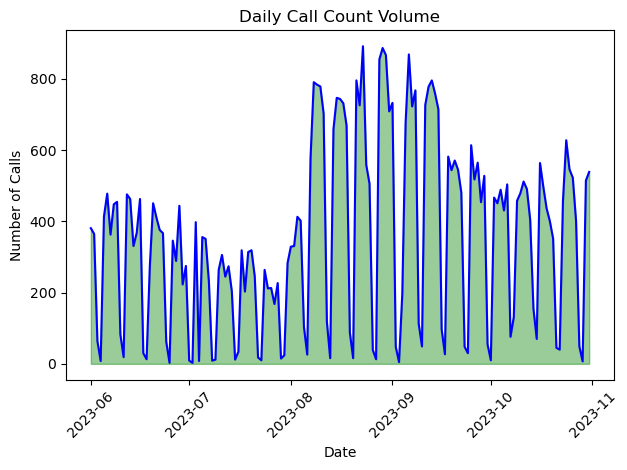

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color= 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha=0.4)

plt.title("Daily Call Count Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley


# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,Thursday
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,Thursday
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,Thursday
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,Thursday
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,Thursday


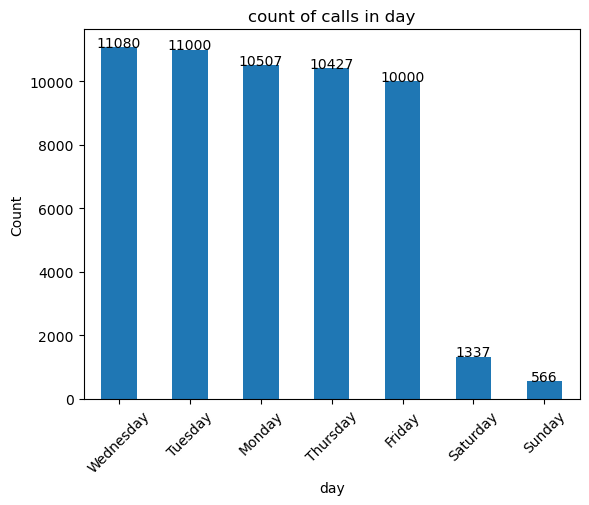

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

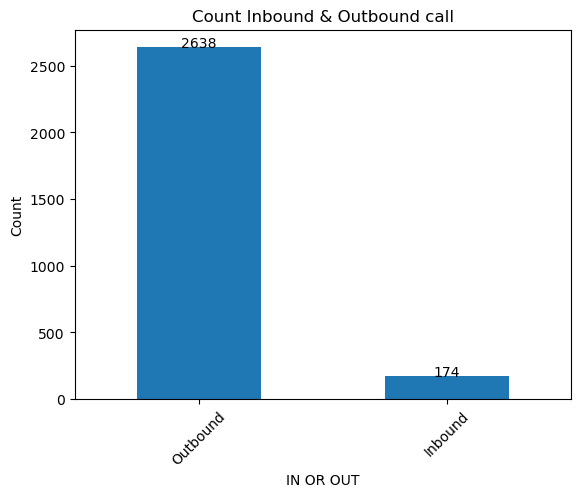

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

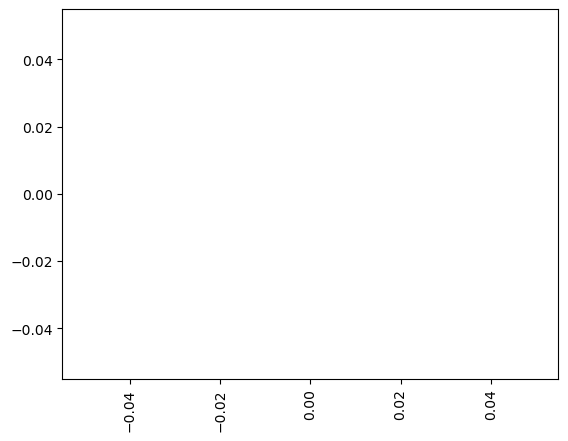

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
167,2023-06-01 14:01:00,Outbound,NaN,Keith Antonio,Thursday
170,2023-06-01 14:03:00,Outbound,NaN,Keith Antonio,Thursday
269,2023-06-01 17:01:00,Outbound,NaN,Jinky Rance,Thursday
272,2023-06-01 17:04:00,Outbound,NaN,Jinky Rance,Thursday
273,2023-06-01 17:07:00,Outbound,NaN,Jinky Rance,Thursday
...,...,...,...,...,...
54402,2023-10-31 10:27:00,Inbound,NaN,Robin Stoehr,Tuesday
54443,2023-10-31 11:19:00,Inbound,NaN,Robin Stoehr,Tuesday
54601,2023-10-31 14:50:00,Outbound,NaN,Robin Stoehr,Tuesday
54657,2023-10-31 15:30:00,Outbound,NaN,Robin Stoehr,Tuesday


In [48]:
df4 = df1.copy()

In [50]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,Thursday
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,Thursday
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,Thursday
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,Thursday
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,Thursday


In [52]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [54]:
(df4['Call duration'] == 0).sum()

0

In [56]:
df4['Call duration'].isnull().sum()

3203

In [58]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 54917 entries, 0 to 54916
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         54917 non-null  datetime64[us]
 1   Call direction        2812 non-null   str           
 2   Call duration         51714 non-null  float64       
 3   Activity assigned to  54917 non-null  str           
 4   day                   54917 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 3.2 MB


In [60]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [62]:
df4 = df4.dropna(subset = ['Call direction'])

In [64]:
df4['Call duration'].isnull().sum()

0

In [66]:
(df4['Call duration'] == 0).sum()

822

In [68]:
df4.info()

<class 'pandas.DataFrame'>
Index: 2812 entries, 0 to 54823
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         2812 non-null   datetime64[us]
 1   Call direction        2812 non-null   str           
 2   Call duration         2812 non-null   float64       
 3   Activity assigned to  2812 non-null   str           
 4   day                   2812 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 209.3 KB


# Working Call Assigner

In [71]:
df1['Activity assigned to'].nunique()

28

In [73]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'Ray Levesque',    'Vladimir Suparto',      'Cameron Dudley',
      'David Banister',         'Adrian Tran',          'Daniel Uli',
         'Jinky Rance',        'Andy Ramirez',        'David Valdez',
       'Tommie Walker',        'Karen Parker',       'Keith Antonio',
        'Dioni Canega',         'Paol Guzman',    'Benjamin Sklivas',
 'Demmie Rose Tamonan',        'Stephen Tarr',    'Chrystel Manabat',
      'Travis Fleming',         'Sal Berdayi',    'Kent Encarnacion',
        'Robin Stoehr',        'Louis Maciel',       'Oliver Martin',
          'True Ellis',    'Colby Rintharamy',           'Terry Kim',
       'Pete Clements']
Length: 28, dtype: str

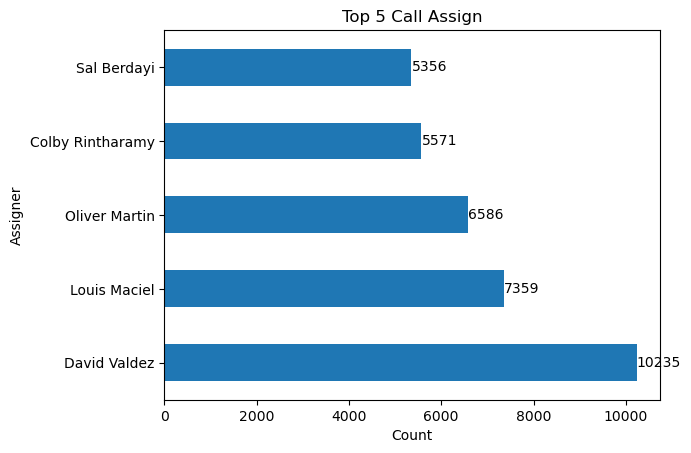

In [75]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# MAX CALL DURATION

In [78]:
df4['Call duration'].max()

99.28333333333333

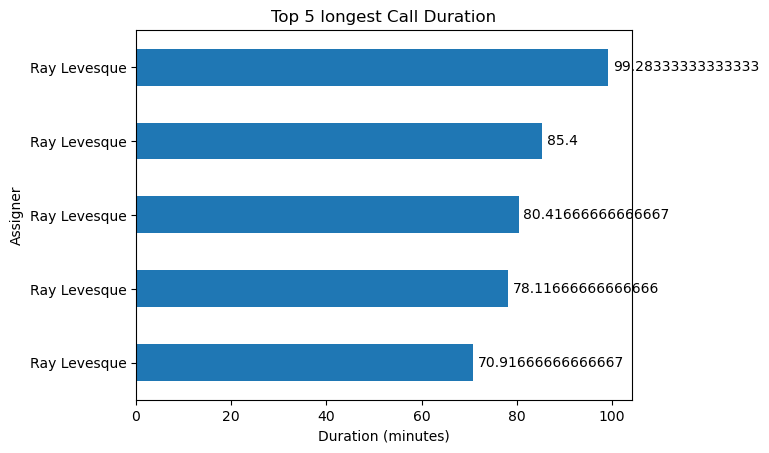

In [80]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call Volume

In [83]:
df3=df1.copy()

In [85]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [87]:
df3['day'].unique()

<ArrowStringArray>
['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday']
Length: 5, dtype: str

In [89]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

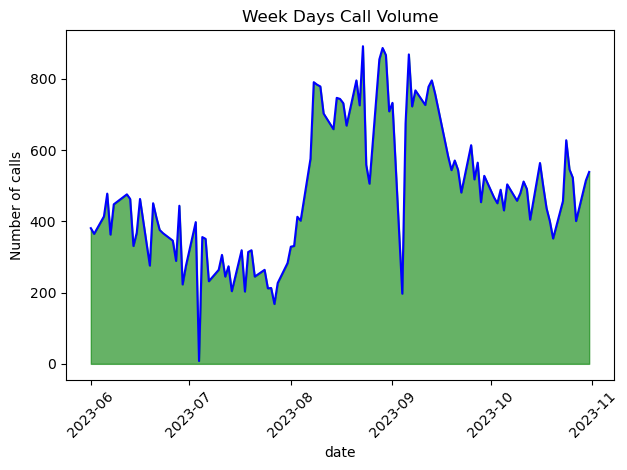

In [91]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [94]:
df5 = df4.copy()

In [96]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [98]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
808,2023-06-03 15:40:00,Inbound,1.0,Ray Levesque,Saturday
3059,2023-06-11 11:09:00,Outbound,0.0,Keith Antonio,Sunday
3060,2023-06-11 11:12:00,Outbound,0.0,Keith Antonio,Sunday
3062,2023-06-11 12:03:00,Outbound,0.0,Keith Antonio,Sunday
3063,2023-06-11 12:10:00,Outbound,0.0,Keith Antonio,Sunday


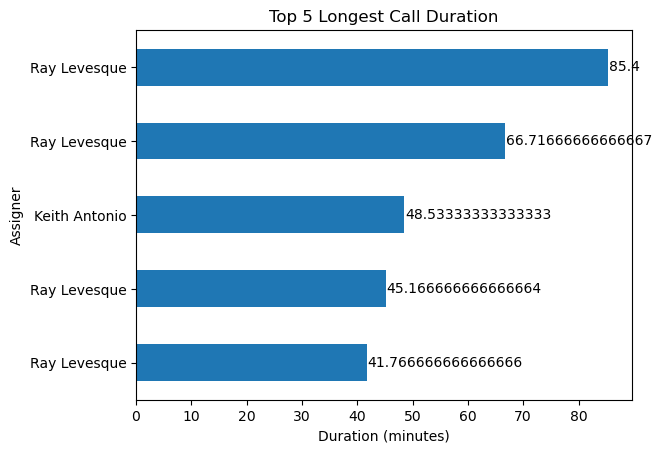

In [100]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

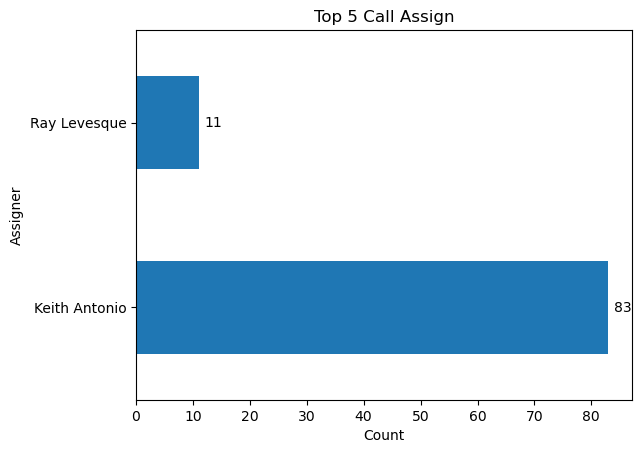

In [103]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [106]:
df6 = df3.copy()

In [108]:
df6['month'] = df6['Activity date'].dt.month_name()

In [110]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,Thursday,June
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,Thursday,June
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,Thursday,June
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,Thursday,June
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,Thursday,June


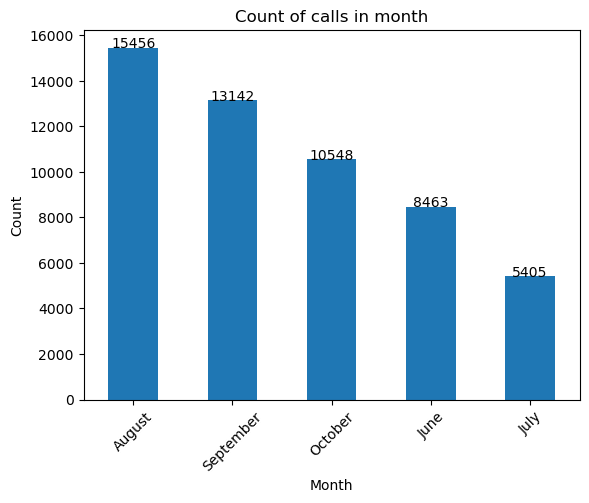

In [112]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Average Call Duration

In [115]:
df4["Call duration"].mean()

4.16628733997155

In [117]:
df4["Call duration"].median()

0.85

# WITHOUT CALL ASSIGNER CALLS

In [120]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [122]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         0 non-null      datetime64[us]
 1   Call direction        0 non-null      str           
 2   Call duration         0 non-null      str           
 3   Activity assigned to  0 non-null      str           
 4   day                   0 non-null      str           
 5   month                 0 non-null      str           
dtypes: datetime64[us](1), str(5)
memory usage: 0.0 bytes


IndexError: index 0 is out of bounds for axis 0 with size 0

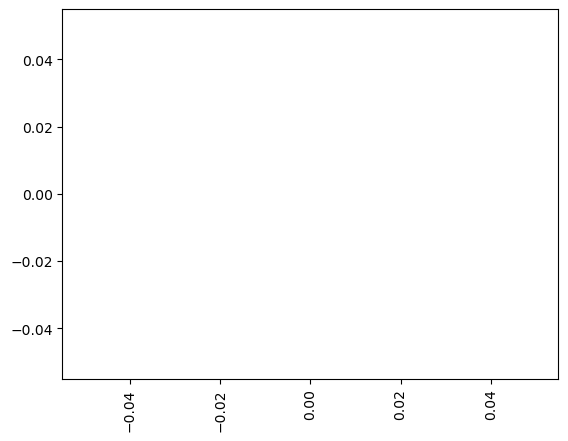

In [124]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# TOP 5 PEAK CALL DATE

In [127]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,2023-06-01
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,2023-06-01
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,2023-06-01
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,2023-06-01
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,2023-06-01


In [129]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [131]:
top5 = daily_calls.sort_values(ascending=False).head(5)

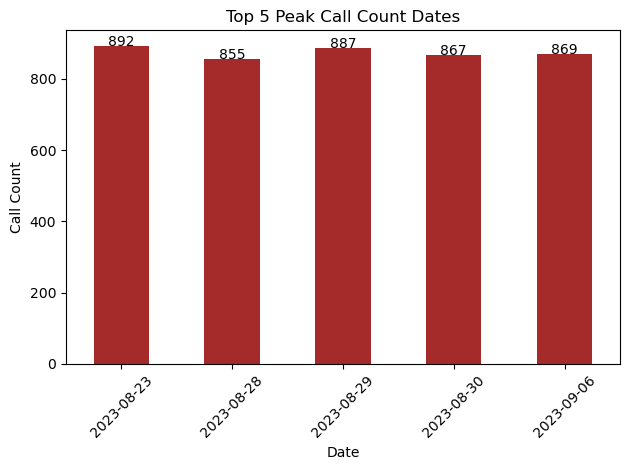

In [133]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()